# Marketing Channel Performance & Attribution

**Author:** Maria Vasilyeva  
**Contact:** mnivasilyeva@gmail.com · Telegram: @MNVasilyeva

## Context

An online store acquires users through paid search, paid social, email, referrals, and organic traffic. Marketing planning requires comparing channel reach and paid orders with each channel's cost and attributed revenue.

## Project objective

Evaluate acquisition-channel performance and provide actionable recommendations for the marketing team using session activity, paid orders, and marketing spend.

## Calculation rules

- channel reach is the number of unique users with at least one session from the channel;
- paying users, orders, and revenue are attributed to the channel of the earliest recorded session;
- only orders with `status = paid` are included in order and revenue metrics;
- all paid orders are counted when a user makes multiple purchases;
- a paying user is a user with at least one paid order;
- marketing spend is aggregated to the channel level;
- CAC and ROMI are not calculated for channels with zero spend.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="rocket")

# 1. Data exploration and preparation

In [5]:
# Load marketing spend, order, and session data
mrkt = pd.read_csv("marketing_spend.csv")
orders = pd.read_csv("orders.csv")
sessions = pd.read_csv("sessions.csv")


In [6]:
# Inspect the dataset structure and data types
mrkt.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   spend_id     100000 non-null  str    
 1   spend_date   100000 non-null  str    
 2   channel      100000 non-null  str    
 3   campaign_id  100000 non-null  str    
 4   ad_group_id  100000 non-null  str    
 5   spend        100000 non-null  float64
dtypes: float64(1), str(5)
memory usage: 4.6 MB


In [7]:
mrkt["channel"].unique()
# The data contains five marketing channels


<StringArray>
['paid_search', 'paid_social', 'email', 'referral', 'organic']
Length: 5, dtype: str

In [8]:
print(orders.info())
print("\n")
print("No missing values")
print("Number of orders:", orders["order_id"].nunique())
print("Unique users in the orders table:", orders["user_id"].nunique())
print("\nOrder statuses:", orders["status"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   order_id    120000 non-null  str  
 1   user_id     120000 non-null  str  
 2   order_date  120000 non-null  str  
 3   status      120000 non-null  str  
 4   revenue     120000 non-null  int64
dtypes: int64(1), str(4)
memory usage: 4.6 MB
None


No missing values
Number of orders: 120000
Unique users in the orders table: 64379

Order statuses: <StringArray>
['cancelled', 'paid', 'refunded']
Length: 3, dtype: str


In [9]:
print(sessions.info())
print("No missing values")
print("\n")
print("Unique users in the sessions table:", sessions["user_id"].nunique())
print("Unique sessions:", sessions["session_id"].nunique())
print("\nDevice types:", sessions["device"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   session_id    160000 non-null  str  
 1   user_id       160000 non-null  str  
 2   session_date  160000 non-null  str  
 3   channel       160000 non-null  str  
 4   device        160000 non-null  str  
dtypes: str(5)
memory usage: 6.1 MB
None
No missing values


Unique users in the sessions table: 85000
Unique sessions: 160000

Device types: <StringArray>
['tablet', 'mobile', 'desktop']
Length: 3, dtype: str


In [10]:
# Convert date fields to datetime 
mrkt["spend_date"] = pd.to_datetime(mrkt["spend_date"])
orders["order_date"]=pd.to_datetime(orders["order_date"])
sessions["session_date"]=pd.to_datetime(sessions["session_date"])

In [11]:
# Keep successfully paid orders only
orders = orders[orders["status"]=="paid"]
print("Number of successfully paid orders:", orders.shape)
orders_per_users = orders.groupby("user_id").agg(orders_cnt=("order_id","nunique")).sort_values("orders_cnt", ascending=False) # Some users placed more than one order
orders_per_users
# Most users placed one order; the maximum was six

Number of successfully paid orders: (56345, 5)


,orders_cnt
user_id,
u059007,6
u044665,6
u069539,6
u037948,6
u076411,5
...,...
u033888,1
u033886,1
u033882,1


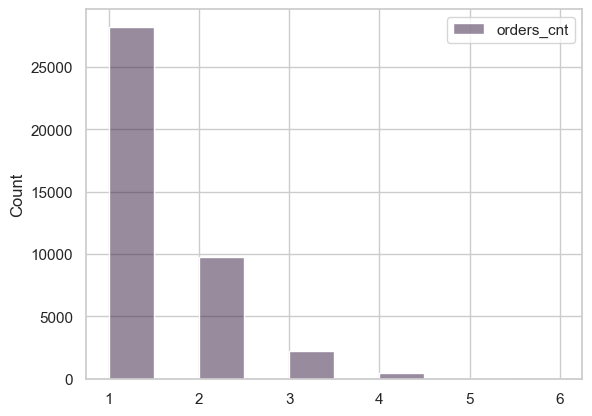

In [12]:
# fig, ax = plt.subplots(figsize=(4,6))
sns.histplot(orders_per_users, bins=10 );

In [13]:
channels_per_users = sessions.groupby("user_id").agg(channels=("channel", "nunique")).sort_values("channels", ascending=False)
channels_per_users
# Most users interacted with one channel; some interacted with up to four

,channels
user_id,
u064823,4
u061700,4
u046115,4
u078509,4
u007895,4
...,...
u031081,1
u031080,1
u031079,1


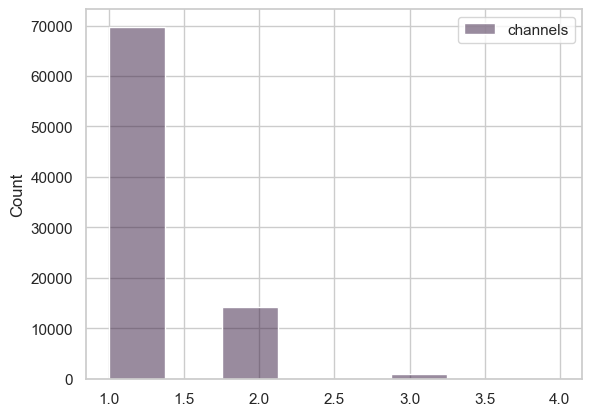

In [14]:
# fig, ax = plt.subplots(figsize=(3,10))
sns.histplot(channels_per_users, bins=8 );

In [15]:
sessions.groupby(["user_id", "channel"]).agg(count=("session_date", "count")).sort_values(by=["user_id","channel","count"], ascending=[True, True, False])
# Users could interact with multiple channels and return through the same channel several times


count
user_id channel           
u000001 email            1
u000002 email            1
u000003 paid_social      1
u000004 paid_social      1
u000005 referral         3
...                    ...
u084997 paid_social      1
        referral         1
u084998 paid_search      2
u084999 paid_social      1
u085000 paid_social      1

[101371 rows x 1 columns]

# 2. Channel performance metrics

This section calculates unique-user reach, paid orders, conversion to paying user, attributed revenue, and average order value.

A consistent first-touch attribution rule is applied: users and their orders are assigned to the channel of the first recorded session.


## Channel reach: unique users

In [16]:
print("Unique users by channel:")
unique_users_per_channel = sessions.groupby("channel").agg(unique_users = ("user_id", "nunique")).sort_values("unique_users", ascending=False)
unique_users_per_channel

Unique users by channel:


,unique_users
channel,
paid_search,31758
organic,22616
paid_social,21798
referral,13133
email,12066


In [ ]:
sns.barplot(unique_users_per_channel, x="channel",y="unique_users")
plt.title("Unique Users by Channel");

## Paid orders

In [18]:
# Enrich paid-order data with user session and channel information
orders_per_channels = pd.merge(sessions, orders, on="user_id", how='right')
orders_per_channels.sort_values(by=["user_id", "order_id","session_date"])


,session_id,user_id,session_date,channel,device,order_id,order_date,status,revenue
17722,s0026899,u000001,2026-01-27,email,mobile,o0092652,2026-02-24,paid,1160
4333,s0005722,u000002,2026-01-07,email,mobile,o0023549,2026-01-29,paid,970
35985,s0005722,u000002,2026-01-07,email,mobile,o0060318,2026-03-16,paid,1250
86681,s0094276,u000005,2026-03-16,referral,mobile,o0007187,2026-04-19,paid,2520
86682,s0101349,u000005,2026-03-20,referral,desktop,o0007187,2026-04-19,paid,2520
...,...,...,...,...,...,...,...,...,...
75703,s0124891,u084995,2026-03-31,paid_search,mobile,o0046526,2026-04-12,paid,2850
75704,s0124892,u084995,2026-03-31,paid_social,mobile,o0046526,2026-04-12,paid,2850
91203,s0023518,u084998,2026-01-23,paid_search,desktop,o0099119,2026-04-21,paid,2370
91204,s0084232,u084998,2026-03-09,paid_search,mobile,o0099119,2026-04-21,paid,2370


In [19]:
# Validate the attribution rule: order o0040888 is assigned to email, the channel of the earliest session
orders_per_channels[orders_per_channels['order_id']=="o0040888"].sort_values("session_date")


,session_id,user_id,session_date,channel,device,order_id,order_date,status,revenue
50146,s0026673,u068855,2026-01-26,email,mobile,o0040888,2026-03-27,paid,960
50147,s0071378,u068855,2026-03-01,organic,mobile,o0040888,2026-03-27,paid,960
50148,s0077482,u068855,2026-03-05,paid_social,mobile,o0040888,2026-03-27,paid,960
50149,s0082277,u068855,2026-03-08,email,desktop,o0040888,2026-03-27,paid,960
50150,s0114325,u068855,2026-03-26,referral,mobile,o0040888,2026-03-27,paid,960
50151,s0143445,u068855,2026-04-16,email,mobile,o0040888,2026-03-27,paid,960


In [20]:
print("Paid orders by channel")
orders_cnt_per_channels = orders_per_channels.sort_values(
    ["order_id", "session_date"]
    ).drop_duplicates("order_id", keep='first'  # Keep the first touchpoint for each order
                      ).groupby("channel"       # Group by channel
                                ).agg(orders_cnt=("order_id","nunique")).sort_values("orders_cnt", ascending=False) # Count unique orders and sort the result
orders_cnt_per_channels

Paid orders by channel


,orders_cnt
channel,
paid_search,21463
organic,13220
referral,7790
paid_social,7211
email,6661


In [ ]:
sns.barplot(orders_cnt_per_channels, x="channel",y="orders_cnt")
plt.title("Paid Orders by Channel");

## First-touch paying users relative to channel reach

The numerator contains paying users attributed by first touch, while the denominator contains all users who interacted with the channel. The metric is therefore interpreted as a comparative diagnostic rate rather than a strict cohort conversion.


In [22]:
# Calculate all users by channel for the conversion denominator
all_users = sessions.groupby("channel").agg(all_users=("user_id","nunique"))

In [23]:
# Inspect the number of paid orders per user
orders.groupby("user_id")["order_id"].count().sort_values(ascending=False)

user_id
u059007    6
u044665    6
u069539    6
u037948    6
u076411    5
          ..
u033888    1
u033886    1
u033882    1
u033880    1
u085000    1
Name: order_id, Length: 40659, dtype: int64

In [24]:
orders_per_channels[orders_per_channels["user_id"]=="u037948"].sort_values(["order_id", "session_date"])
# This user's first session was organic, so all orders are attributed to organic despite later paid-search visits.


,session_id,user_id,session_date,channel,device,order_id,order_date,status,revenue
95684,s0005177,u037948,2026-01-06,organic,mobile,o0067886,2026-04-24,paid,1460
95685,s0100323,u037948,2026-03-19,paid_search,mobile,o0067886,2026-04-24,paid,1460
95686,s0155829,u037948,2026-04-27,organic,desktop,o0067886,2026-04-24,paid,1460
21399,s0005177,u037948,2026-01-06,organic,mobile,o0072584,2026-03-01,paid,1340
21400,s0100323,u037948,2026-03-19,paid_search,mobile,o0072584,2026-03-01,paid,1340
21401,s0155829,u037948,2026-04-27,organic,desktop,o0072584,2026-03-01,paid,1340
1749,s0005177,u037948,2026-01-06,organic,mobile,o0095759,2026-01-18,paid,1940
1750,s0100323,u037948,2026-03-19,paid_search,mobile,o0095759,2026-01-18,paid,1940
1751,s0155829,u037948,2026-04-27,organic,desktop,o0095759,2026-01-18,paid,1940
5849,s0005177,u037948,2026-01-06,organic,mobile,o0097634,2026-02-02,paid,1370


In [25]:
# Calculate the conversion numerator: each paying user is assigned to the channel of their first session
paid_users = orders_per_channels.sort_values(
    ["user_id", "session_date"]
    ).drop_duplicates("user_id", keep='first'  # Keep the first touchpoint for each user
                      ).groupby("channel"       # Group by channel
                                ).agg(paid_users=("user_id","nunique")).sort_values("paid_users", ascending=False) # Count paying users and sort the result
paid_users

,paid_users
channel,
paid_search,15288
organic,9605
paid_social,5923
referral,5276
email,4567


In [26]:
print("Conversion to paying user")
conversion = pd.merge(all_users, paid_users, on="channel")
conversion["conversion"] = round(conversion["paid_users"]*100/conversion["all_users"], 2)
conversion.sort_values("conversion", ascending=False)

First-touch paying users relative to channel reach


,all_users,paid_users,conversion
channel,,,
paid_search,31758,15288,48.14
organic,22616,9605,42.47
referral,13133,5276,40.17
email,12066,4567,37.85
paid_social,21798,5923,27.17


In [ ]:
sns.barplot(conversion.sort_values("conversion", ascending=False), x="channel",y="conversion")
plt.title("Conversion to Paying User by Channel");

## Revenue from paid orders

In [28]:
# Revenue is the sum of revenue from all unique paid orders by channel
print("Revenue by channel")
total_revenue = orders_per_channels.sort_values(
    ["order_id", "session_date"]
    ).drop_duplicates("order_id", keep='first'  # Keep the first touchpoint for each order
                      ).groupby("channel"       # Group by channel
                                ).agg(total_revenue=("revenue","sum")).sort_values("total_revenue", ascending=False) # Sum attributed revenue and sort the result
total_revenue

Revenue by channel


,total_revenue
channel,
paid_search,35121030
referral,20260630
organic,18053060
paid_social,8028800
email,6306120


In [ ]:
sns.barplot(total_revenue, x="channel",y="total_revenue")
plt.title("Revenue by Channel");

## Average order value

In [30]:
# AOV — Average Order Value
print("Average order value by channel")
orders_per_channels.sort_values(
    ["order_id", "session_date"]
    ).drop_duplicates("order_id", keep='first'  # Keep the first touchpoint for each order
                      ).groupby("channel"       # Group by channel
                                ).agg(aov=("revenue",lambda x: round(x.mean(), 2))).sort_values("aov", ascending=False) # Calculate average order value and sort the result

Average order value by channel


,aov
channel,
referral,2600.85
paid_search,1636.35
organic,1365.59
paid_social,1113.41
email,946.72


# 3. Marketing investment efficiency

## CAC — customer acquisition cost per paying user

```text
CAC = marketing spend / number of paying users
```


In [31]:
mrkt.sample(3)

,spend_id,spend_date,channel,campaign_id,ad_group_id,spend
29295,m0029296,2026-03-27,email,ema_c025,ag007,193.30
53246,m0053247,2026-01-12,paid_search,pai_c045,ag004,1108.57
54040,m0054041,2026-01-23,email,ema_c028,ag017,228.05


In [32]:
# Aggregate marketing spend by channel
total_spend = mrkt.groupby("channel").agg(total_spend=("spend", "sum")).sort_values("total_spend", ascending=False)
CAC = pd.merge(total_spend, paid_users, on = "channel")
CAC["CAC"] = np.where(CAC["total_spend"]>0, round(CAC["total_spend"] / CAC["paid_users"],2), np.nan)
CAC.sort_values("CAC", ascending=False)

,total_spend,paid_users,CAC
channel,,,
paid_social,13842758.62,5923,2337.12
paid_search,28787729.51,15288,1883.03
referral,7108992.98,5276,1347.42
email,3821890.91,4567,836.85
organic,0.00,9605,NaN


Paid social was the most expensive paid channel, with a CAC of **2,337.12** per paying user.

Paid search ranked second by CAC (**1,883.03**) but acquired approximately 2.6 times more paying users than paid social.

Organic traffic had no direct marketing spend and still ranked second by the number of paying users.


## ROMI — return on marketing investment

```text
ROMI = (revenue − marketing spend) / marketing spend
```


In [33]:
ROMI = pd.merge(total_revenue, CAC, on="channel")
ROMI = ROMI[["total_revenue","total_spend"]]
ROMI["ROMI"] = np.where(ROMI["total_spend"]>0, round((ROMI["total_revenue"] - ROMI["total_spend"]) / ROMI["total_spend"],2), np.nan)
ROMI.sort_values("ROMI", ascending=False)

,total_revenue,total_spend,ROMI
channel,,,
referral,20260630,7108992.98,1.85
email,6306120,3821890.91,0.65
paid_search,35121030,28787729.51,0.22
paid_social,8028800,13842758.62,-0.42
organic,18053060,0.00,NaN


In [ ]:
colors = ["crimson" if x < 0 else "steelblue" for x in ROMI.sort_values("ROMI", ascending=False)["ROMI"]]

sns.barplot(ROMI.sort_values("ROMI", ascending=False), x="channel",y="ROMI", palette=colors)
plt.title("ROMI by Channel");

ROMI shows the additional attributed revenue generated above each unit of marketing spend.

- **Referral** was the best-performing paid channel, with a ROMI of **1.85**. Each unit of spend generated 1.85 units of revenue above marketing cost.
- **Email** delivered a positive ROMI (**0.65**) with a comparatively low CAC.
- **Paid search** was also profitable, although its ROMI was substantially lower (**0.22**).
- **Paid social** had a negative ROMI (**−0.42**), meaning attributed revenue did not cover marketing spend.
- ROMI was not calculated for **organic** because its direct spend was zero.


# 4. Conclusions and recommendations

1. **Referral was the most efficient paid channel.** It combined the highest ROMI (**1.85**), a comparatively low CAC (**1,347.42**), and the highest average order value (**2,600.85**). The channel is a candidate for scaling, provided that its efficiency remains stable at higher volume.

2. **Paid social requires a detailed review.** It had the highest CAC (**2,337.12**), the lowest conversion to paying user (**27.17%**), and a negative ROMI (**−0.42**). The next step is to analyze performance by campaign and ad group and assess the quality of the acquired audience.

3. **Email was a low-cost, profitable channel.** Although it generated a relatively small share of total revenue, it delivered a low CAC (**836.85**) and a positive ROMI (**0.65**). Increasing reach and testing communication scenarios may improve its contribution.

4. **Paid search delivered scale but operated with a limited return relative to spend.** It acquired the largest number of paying users and generated the highest revenue, but its ROMI was only **0.22**. Campaign and keyword optimization should focus on improving efficiency without losing volume.

5. **The results depend on the attribution model.** Users interacted with multiple channels before purchasing, so first-touch attribution may over-credit discovery channels and under-credit channels closer to conversion. The findings should be tested against last-touch and multi-touch attribution approaches.
